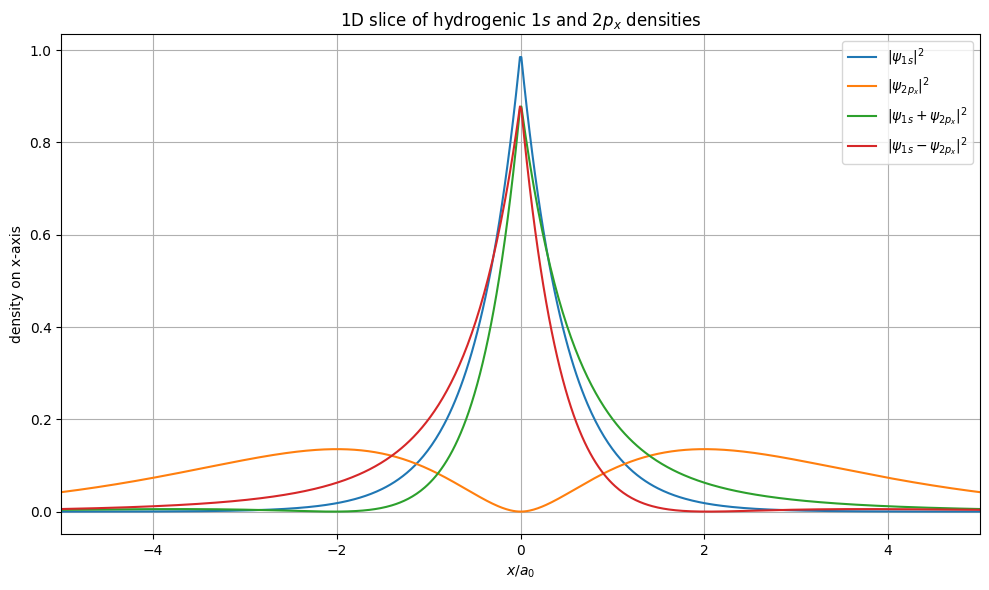

In [5]:
import numpy as onp
import jax.numpy as np
import matplotlib.pyplot as plt

# Bohr radius; use a0 = 1.0 for atomic units
a0 = 1.0

# 1D slice along the x-axis
x = np.linspace(-15.0 * a0, 15.0 * a0, 2000)
r = np.abs(x)

# Hydrogen 1s orbital evaluated on the x-axis
# psi_1s(r) = (1 / sqrt(pi a0^3)) * exp(-r / a0)
psi_1s = (1.0 / np.sqrt(np.pi * a0**3)) * np.exp(-r / a0)

# Hydrogen 2p_x orbital evaluated on the x-axis
# psi_2p_x(x,0,0) = x / (4 sqrt(2 pi) a0^(5/2)) * exp(-r / (2 a0))
psi_2px = x / (4.0 * np.sqrt(2.0 * np.pi) * a0**(5.0 / 2.0)) * np.exp(-r / (2.0 * a0))

# Individual densities
rho_1s = np.abs(psi_1s)**2
rho_2px = np.abs(psi_2px)**2

# Superpositions
psi_plus = psi_1s + psi_2px
psi_minus = psi_1s - psi_2px

rho_plus = np.abs(psi_plus)**2
rho_minus = np.abs(psi_minus)**2

# Optional: if you want normalized line plots for easier visual comparison,
# uncomment these lines. Note that this is normalization along the x-axis only,
# not full 3D normalization.
def normalize_line_density(rho, x):
  return rho / np.trapezoid(rho, x)

rho_1s = normalize_line_density(rho_1s, x)
rho_2px = normalize_line_density(rho_2px, x)
rho_plus = normalize_line_density(rho_plus, x)
rho_minus = normalize_line_density(rho_minus, x)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x / a0, rho_1s, label=r"$|\psi_{1s}|^2$")
ax.plot(x / a0, rho_2px, label=r"$|\psi_{2p_x}|^2$")
ax.plot(x / a0, rho_plus, label=r"$|\psi_{1s} + \psi_{2p_x}|^2$")
ax.plot(x / a0, rho_minus, label=r"$|\psi_{1s} - \psi_{2p_x}|^2$")

ax.set(
  xlabel=r"$x / a_0$",
  ylabel="density on x-axis",
  title=r"1D slice of hydrogenic $1s$ and $2p_x$ densities"
)
ax.set(
	xlim=(-5,5)
)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()